<a href="https://colab.research.google.com/github/Suhani0411/Lung-Cancer-Detection/blob/main/Proj_Lung_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lung Cancer Detection from CT Scan Images
This notebook classifies lung CT scan images into four categories using a custom Convolutional Neural Network (CNN) built from scratch.

**Dataset:** Kaggle Chest CT-Scan Images Dataset

**Classes:**
* `adenocarcinoma` - Most common lung cancer type
* `large_cell_carcinoma` - Fast-growing cancer
* `squamous_cell_carcinoma` - Found in central lung area
* `normal` - Healthy lung tissue

**Model:** Custom CNN with 4 convolutional blocks

## 1. Setup

In [ ]:
# Install required packages
!pip install torch torchvision matplotlib seaborn scikit-learn numpy pillow kagglehub tqdm -q

In [ ]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set random seed
np.random.seed(42)
torch.manual_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Download Dataset

In [ ]:
# Download dataset from Kaggle
import kagglehub

print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
print(f"Downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'chest-ctscan-images' dataset.
Downloaded to: /kaggle/input/chest-ctscan-images


In [ ]:
# Find data directories
for root, dirs, files in os.walk(dataset_path):
    if 'train' in dirs:
        train_path = os.path.join(root, 'train')
        test_path = os.path.join(root, 'test')
        valid_path = os.path.join(root, 'valid')
        break

print(f"Train path: {train_path}")
print(f"Test path: {test_path}")
print(f"Valid path: {valid_path}")

Train path: /kaggle/input/chest-ctscan-images/Data/train
Test path: /kaggle/input/chest-ctscan-images/Data/test
Valid path: /kaggle/input/chest-ctscan-images/Data/valid


## 3. Explore the Data

In [ ]:
# Get class names and count images
classes = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
print(f"Classes: {classes}")

# Count images per class
print("\nImages per class (Training):")
for cls in classes:
    count = len([f for f in os.listdir(os.path.join(train_path, cls)) if f.endswith(('.png', '.jpg', '.jpeg'))])
    print(f"  {cls}: {count}")

Classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']

Images per class (Training):
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115
  normal: 148
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155


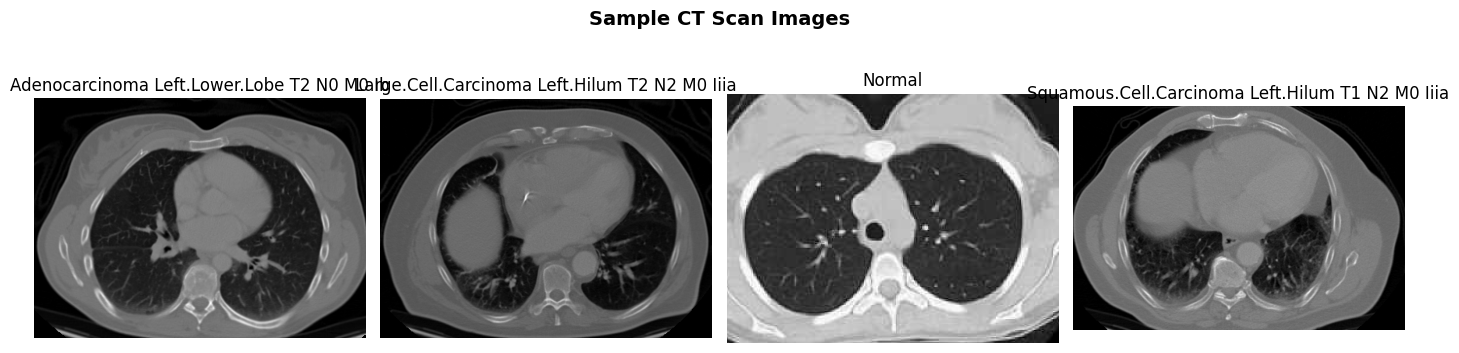

In [ ]:
# Display sample images
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_path, cls)
    img_name = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, img_name))

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cls.replace('_', ' ').title())
    axes[i].axis('off')

plt.suptitle('Sample CT Scan Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Prepare Data

In [ ]:
# Image transformations
IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
# Dataset class
class LungDataset(Dataset):
    def __init__(self, root_dir, transform):
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.images = []
        self.labels = []

        for idx, cls in enumerate(self.classes):
            cls_path = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_path):
                if img_name.endswith(('.png', '.jpg', '.jpeg')):
                    self.images.append(os.path.join(cls_path, img_name))
                    self.labels.append(idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        return self.transform(image), self.labels[idx]

# Create datasets
train_dataset = LungDataset(train_path, train_transform)
valid_dataset = LungDataset(valid_path, test_transform)
test_dataset = LungDataset(test_path, test_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(valid_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 613
Validation samples: 72
Test samples: 315


In [ ]:
# Create data loaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batch size: {BATCH_SIZE}")

Batch size: 32


## 5. Build CNN Model

In [ ]:
# Custom CNN Model
class LungCancerCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(LungCancerCNN, self).__init__()

        # Convolutional Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Convolutional Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Convolutional Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Convolutional Block 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.fc(x)
        return x

# Create model
model = LungCancerCNN(num_classes=len(classes)).to(device)
print(model)

LungCancerCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Ba

In [ ]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 8,780,548
Trainable parameters: 8,780,548


## 6. Train the Model

In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [ ]:
# Training function
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), correct / total

# Validation function
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), correct / total

In [ ]:
# Train the model
EPOCHS = 100

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []
best_valid_acc = 0.0

print("Starting training...")
print("=" * 60)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    valid_loss, valid_acc = validate(model, valid_loader, criterion)

    scheduler.step(valid_loss)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)

    # Save best model
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

print("=" * 60)
print(f"Best Validation Accuracy: {best_valid_acc:.4f}")

Starting training...
Epoch  1/100 | Train Loss: 4.2287 | Train Acc: 0.4454 | Valid Loss: 1.2783 | Valid Acc: 0.4167
Epoch  2/100 | Train Loss: 2.3637 | Train Acc: 0.4780 | Valid Loss: 1.1046 | Valid Acc: 0.4444
Epoch  3/100 | Train Loss: 1.2882 | Train Acc: 0.5546 | Valid Loss: 0.9716 | Valid Acc: 0.4444
Epoch  4/100 | Train Loss: 1.0158 | Train Acc: 0.5612 | Valid Loss: 1.1195 | Valid Acc: 0.4583
Epoch  5/100 | Train Loss: 0.9107 | Train Acc: 0.6003 | Valid Loss: 0.9458 | Valid Acc: 0.6528
Epoch  6/100 | Train Loss: 0.8492 | Train Acc: 0.6199 | Valid Loss: 0.8730 | Valid Acc: 0.6111
Epoch  7/100 | Train Loss: 0.8104 | Train Acc: 0.6493 | Valid Loss: 0.9498 | Valid Acc: 0.5694
Epoch  8/100 | Train Loss: 0.8090 | Train Acc: 0.6623 | Valid Loss: 0.8512 | Valid Acc: 0.7083
Epoch  9/100 | Train Loss: 0.7469 | Train Acc: 0.6591 | Valid Loss: 0.7986 | Valid Acc: 0.6111
Epoch 10/100 | Train Loss: 0.7318 | Train Acc: 0.6705 | Valid Loss: 0.8139 | Valid Acc: 0.5694
Epoch 11/100 | Train Loss: 0.

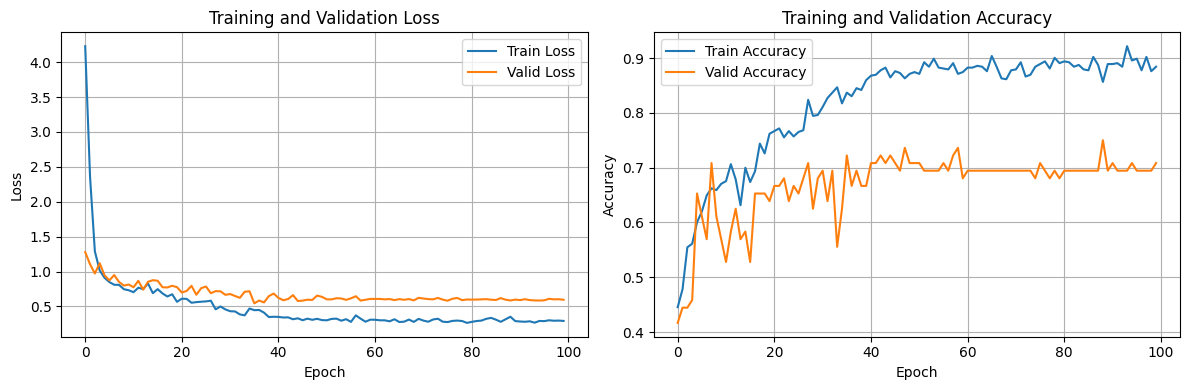

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(valid_losses, label='Valid Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(valid_accs, label='Valid Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluate Model

In [ ]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Get predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

y_test = np.array(all_labels)
y_pred = np.array(all_preds)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Accuracy: 0.5270 (52.70%)


In [ ]:
# Classification report
print("\nClassification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=classes))


Classification Report:
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.49      0.19      0.28       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.46      0.90      0.61        51
                                          normal       0.51      0.98      0.67        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.68      0.49      0.57        90

                                        accuracy                           0.53       315
                                       macro avg       0.54      0.64      0.53       315
                                    weighted avg       0.54      0.53      0.48       315



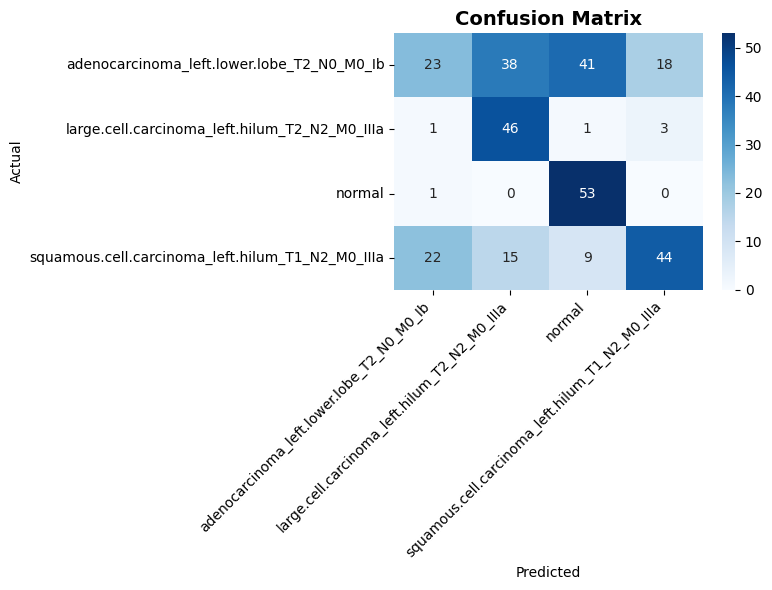

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Visualize Predictions

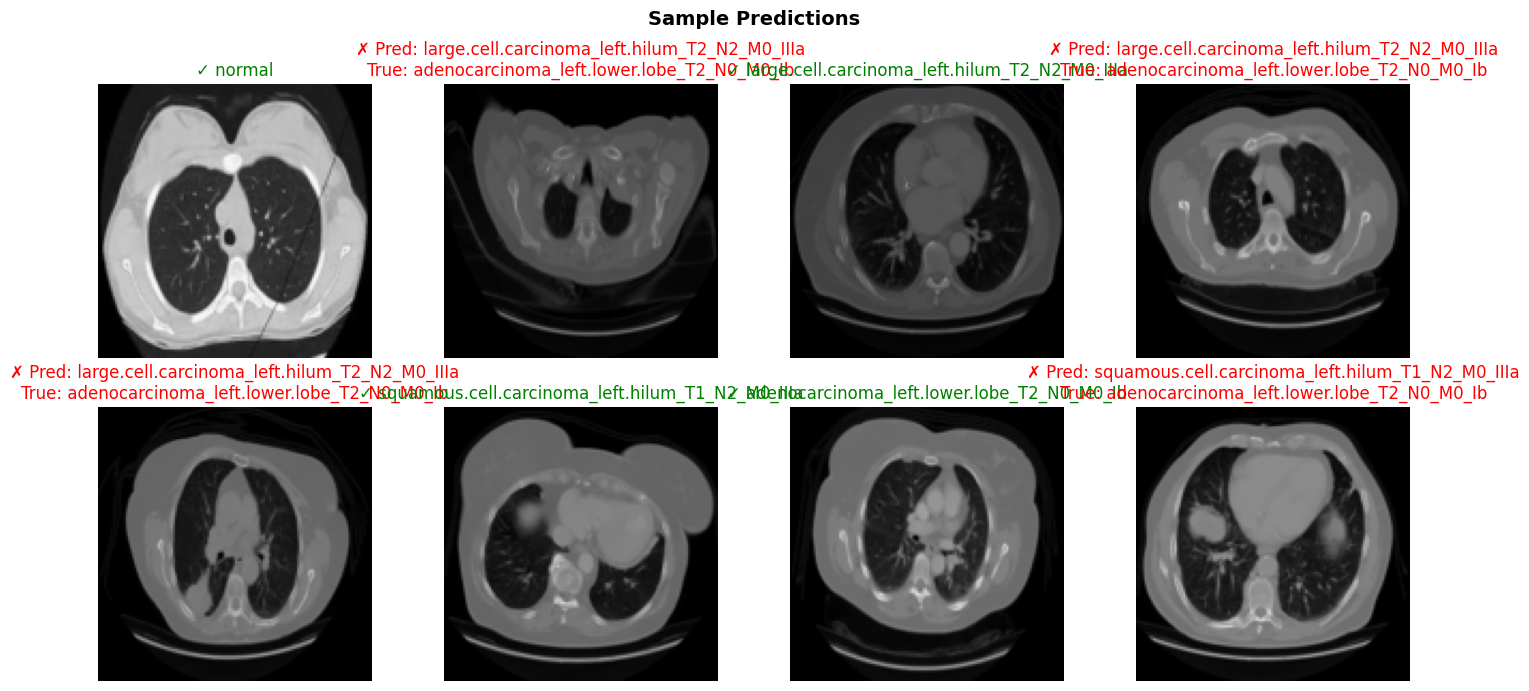

In [ ]:
# Show sample predictions
def denormalize(tensor):
    return tensor * 0.5 + 0.5

# Get random samples
n_samples = 8
indices = np.random.choice(len(test_dataset), n_samples, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for i, idx in enumerate(indices):
    image, true_label = test_dataset[idx]
    pred_label = y_pred[idx]

    img = denormalize(image).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    if true_label == pred_label:
        axes[i].set_title(f'✓ {classes[pred_label]}', color='green')
    else:
        axes[i].set_title(f'✗ Pred: {classes[pred_label]}\nTrue: {classes[true_label]}', color='red')
    axes[i].axis('off')

plt.suptitle('Sample Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()